Prévision des rendements et de la volatilité des portefeuilles actions

Et dans l’introduction tu précises :

L’étude compare des portefeuilles SMALL et BIG.

# I) MODELE ARIMA

### STATIONNARITE

In [3]:
import pandas as pd

df = pd.read_excel("data_FF_PF.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

df.tail()

,SMALL_LoINV,BIG_LoINV,Mkt_RF,SMB,HML,RMW,CMA,RF,SMALL_LoINV_RF,BIG_LoINV_RF
Date,,,,,,,,,,
2025-08-01,8.5853,2.6250,1.85,4.88,4.42,-0.68,2.08,0.38,8.2053,2.2450
2025-09-01,1.7515,1.2317,3.39,-2.18,-1.05,-2.06,-2.22,0.33,1.4215,0.9017
2025-10-01,0.1526,-1.0086,1.96,-1.31,-3.09,-5.21,-4.03,0.37,-0.2174,-1.3786
2025-11-01,0.8422,1.9683,-0.13,1.47,3.76,1.42,0.68,0.30,0.5422,1.6683
2025-12-01,-0.3110,0.8909,-0.36,-0.22,2.42,0.40,0.37,0.34,-0.6510,0.5509


In [63]:
df.head()

,SMALL_LoINV,BIG_LoINV,Mkt_RF,SMB,HML,RMW,CMA,RF,SMALL_LoINV_RF,BIG_LoINV_RF
Date,,,,,,,,,,
1990-09-01,-8.4158,-3.0630,-6.11,-3.72,0.59,0.03,3.62,0.60,-9.0158,-3.6630
1990-10-01,-7.6045,-1.7428,-1.91,-5.06,0.08,3.17,-0.25,0.68,-8.2845,-2.4228
1990-11-01,4.7890,4.8497,6.35,0.02,-2.97,0.58,-4.71,0.57,4.2190,4.2797
1990-12-01,2.3097,2.2147,2.48,0.60,-1.57,2.66,-1.98,0.60,1.7097,1.6147
1991-01-01,8.9428,0.9829,4.69,3.87,-1.48,1.34,-4.07,0.52,8.4228,0.4629


Les portefeuilles SMALL LoINV et BIG LoINV sont des portefeuilles théoriques construits à des fins de recherche académique. Ils regroupent les entreprises classées selon leur taille et leur taux d’investissement, et leur rendement correspond à la moyenne pondérée des actions composant chaque groupe. Il ne s’agit pas de fonds d’investissement réels mais de portefeuilles synthétiques utilisés pour l’analyse des facteurs de risque.

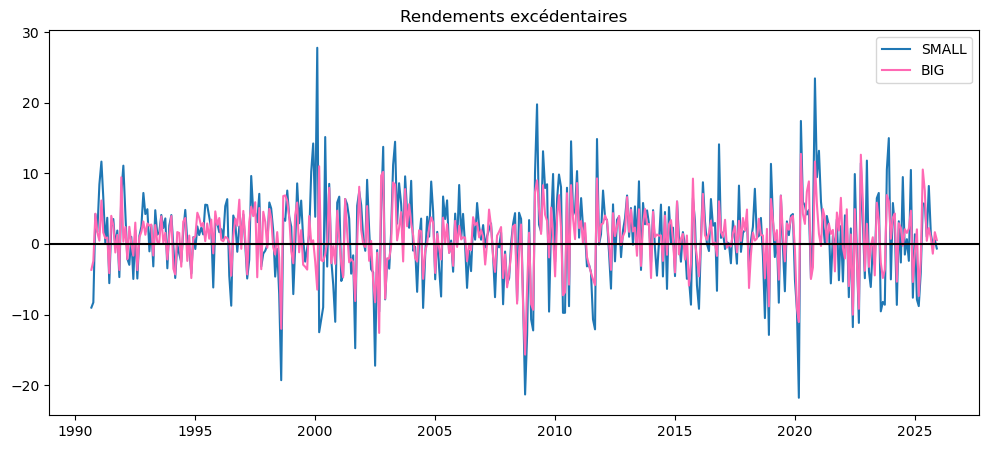

In [65]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

plt.plot(df.index, df["SMALL_LoINV_RF"], label="SMALL")
plt.plot(df.index, df["BIG_LoINV_RF"], label="BIG", color="#FF69B4")

plt.axhline(0, color="black")

# afficher une graduation tous les 5 ans
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Rendements excédentaires")
plt.legend()

plt.savefig("rendements excedentaires.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    
    print(f"\nTest ADF pour {name}")
    print("Statistique ADF :", round(result[0], 4))
    print("p-value :", round(result[1], 6))
    print("Nombre de lags utilisés :", result[2])
    print("Nombre d'observations :", result[3])
    
    if result[1] < 0.05:
        print("→ Série stationnaire (rejet H0)")
    else:
        print("→ Série NON stationnaire (on ne rejette pas H0)")

# Test sur les deux portefeuilles
adf_test(df["SMALL_LoINV_RF"], "SMALL_LoINV_RF")
adf_test(df["BIG_LoINV_RF"], "BIG_LoINV_RF")


Test ADF pour SMALL_LoINV_RF
Statistique ADF : -19.1345
p-value : 0.0
Nombre de lags utilisés : 0
Nombre d'observations : 423
→ Série stationnaire (rejet H0)

Test ADF pour BIG_LoINV_RF
Statistique ADF : -15.8854
p-value : 0.0
Nombre de lags utilisés : 1
Nombre d'observations : 422
→ Série stationnaire (rejet H0)


Le nombre de retards est sélectionné automatiquement par le critère AIC. Le portefeuille BIG nécessite un retard supplémentaire afin de corriger une légère autocorrélation résiduelle, tandis que le portefeuille SMALL ne nécessite aucun retard additionnel. Cette différence reflète des dynamiques temporelles légèrement distinctes entre les deux séries.


### SPECIFICATION DU MODELE ARIMA

On trace les fonctions d’autocorrélation (ACF) et d’autocorrélation partielle (PACF) afin d’identifier la présence de dépendances temporelles dans la série et de déterminer les ordres appropriés 
𝑝
p (AR) et 
𝑞
q (MA) du modèle ARIMA.

Ces graphiques permettent donc de justifier économétriquement le choix de la spécification du modèle plutôt que de sélectionner les paramètres de manière arbitraire.

<Figure size 1200x400 with 0 Axes>

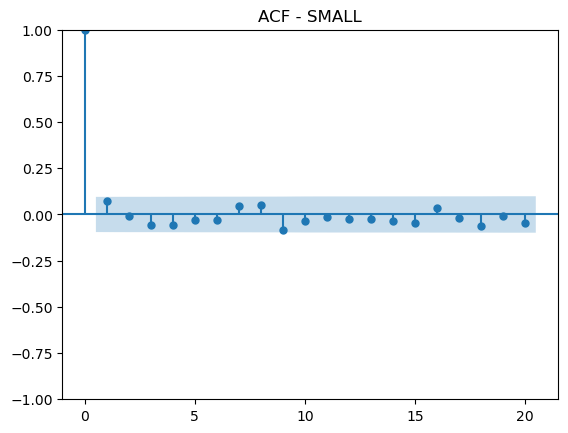

<Figure size 1200x400 with 0 Axes>

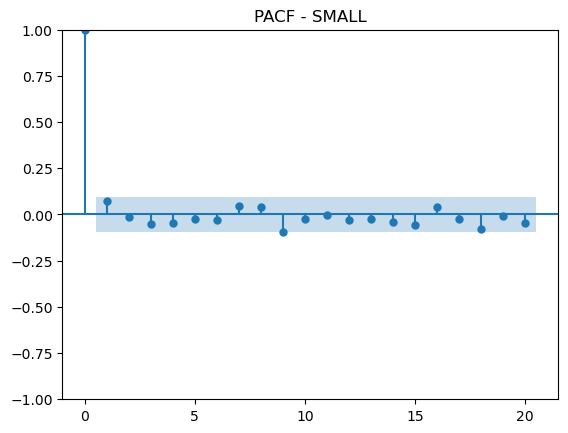

In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(df["SMALL_LoINV_RF"], lags=20)
plt.title("ACF - SMALL")
plt.savefig("acfsmall.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df["SMALL_LoINV_RF"], lags=20)
plt.title("PACF - SMALL")
plt.savefig("pacfsmall.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1200x400 with 0 Axes>

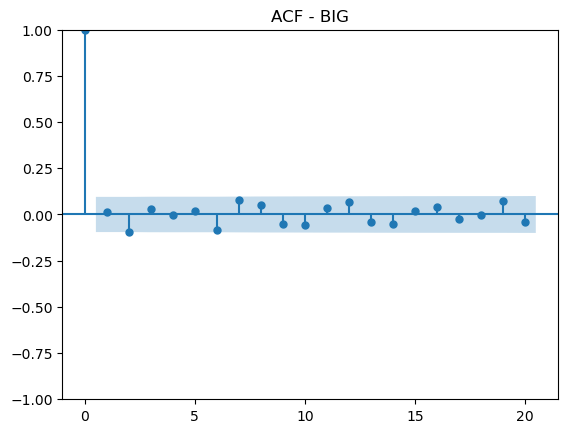

<Figure size 1200x400 with 0 Axes>

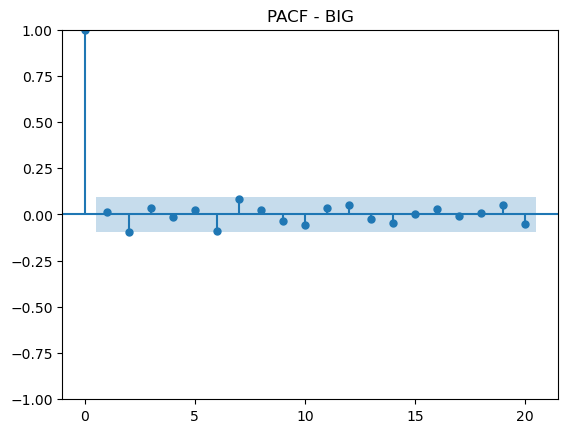

In [76]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(df["BIG_LoINV_RF"], lags=20)
plt.title("ACF - BIG")
plt.savefig("acfbig.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df["BIG_LoINV_RF"], lags=20)
plt.title("PACF - BIG")
plt.savefig("pacfbig.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf

def acf_pacf_tables(series, nlags=20, name=""):
    rdt = series.dropna()

    # ACF
    coef_acf, ci_acf = acf(rdt, nlags=nlags, alpha=0.05)
    acf_table = pd.DataFrame({
        "lag": range(len(coef_acf)),
        "acf": coef_acf,
        "ci_low": ci_acf[:, 0],
        "ci_high": ci_acf[:, 1],
    })
    acf_table["significant"] = (acf_table["ci_low"] > 0) | (acf_table["ci_high"] < 0)

    # PACF (méthode explicite pour éviter bugs/erreurs)
    coef_pacf, ci_pacf = pacf(rdt, nlags=nlags, alpha=0.05, method="ywm")
    pacf_table = pd.DataFrame({
        "lag": range(len(coef_pacf)),
        "pacf": coef_pacf,
        "ci_low": ci_pacf[:, 0],
        "ci_high": ci_pacf[:, 1],
    })
    pacf_table["significant"] = (pacf_table["ci_low"] > 0) | (pacf_table["ci_high"] < 0)

    print(f"\n=== {name} ===")
    print("ACF (top lags):")
    print(acf_table.head(10))
    print("\nPACF (top lags):")
    print(pacf_table.head(10))

    return acf_table, pacf_table

# SMALL
acf_small, pacf_small = acf_pacf_tables(df["SMALL_LoINV_RF"], nlags=20, name="SMALL_LoINV_RF")

# BIG
acf_big, pacf_big = acf_pacf_tables(df["BIG_LoINV_RF"], nlags=20, name="BIG_LoINV_RF")


=== SMALL_LoINV_RF ===
ACF (top lags):
   lag       acf    ci_low   ci_high  significant
0    0  1.000000  1.000000  1.000000         True
1    1  0.072605 -0.022579  0.167789        False
2    2 -0.008095 -0.103780  0.087590        False
3    3 -0.054789 -0.150479  0.040902        False
4    4 -0.055705 -0.151679  0.040270        False
5    5 -0.030526 -0.126793  0.065741        False
6    6 -0.029656 -0.126011  0.066699        False
7    7  0.045636 -0.050801  0.142074        False
8    8  0.049813 -0.046820  0.146446        False
9    9 -0.083692 -0.180558  0.013173        False

PACF (top lags):
   lag      pacf    ci_low   ci_high  significant
0    0  1.000000  1.000000  1.000000         True
1    1  0.072605 -0.022579  0.167789        False
2    2 -0.013437 -0.108621  0.081747        False
3    3 -0.053509 -0.148693  0.041675        False
4    4 -0.048305 -0.143490  0.046879        False
5    5 -0.024313 -0.119497  0.070872        False
6    6 -0.029868 -0.125052  0.065317      

L’analyse des fonctions d’autocorrélation et d’autocorrélation partielle ne met en évidence aucune structure dynamique claire. Les rares coefficients significatifs apparaissent isolés et de faible amplitude, suggérant un comportement proche du bruit blanc. Les critères d’information confirment qu’un modèle ARMA(0,0) est suffisant pour modéliser la moyenne des rendements.

Bien que les graphiques ACF et PACF ne révèlent pas de dépendance temporelle significative, une estimation ARIMA est réalisée afin de confirmer empiriquement l’absence ou la présence d’une structure dynamique faible, détectable via les critères d’information (AIC/BIC).

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def grid_search_arima(series, p_max=6, q_max=6, d=0):
    series = series.dropna()
    results = []
    
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                fit = model.fit()
                results.append({
                    "order": (p, d, q),
                    "AIC": fit.aic,
                    "BIC": fit.bic
                })
            except:
                continue
    
    res = pd.DataFrame(results).sort_values(["AIC", "BIC"]).reset_index(drop=True)
    best_aic = res.iloc[0]
    best_bic = res.sort_values("BIC").iloc[0]
    return res, best_aic, best_bic

# SMALL
res_small, best_aic_small, best_bic_small = grid_search_arima(df["SMALL_LoINV_RF"], p_max=6, q_max=6, d=0)
print("SMALL - meilleur AIC :", best_aic_small["order"], "AIC=", round(best_aic_small["AIC"],3), "BIC=", round(best_aic_small["BIC"],3))
print("SMALL - meilleur BIC :", best_bic_small["order"], "AIC=", round(best_bic_small["AIC"],3), "BIC=", round(best_bic_small["BIC"],3))

# BIG
res_big, best_aic_big, best_bic_big = grid_search_arima(df["BIG_LoINV_RF"], p_max=6, q_max=6, d=0)
print("BIG   - meilleur AIC :", best_aic_big["order"], "AIC=", round(best_aic_big["AIC"],3), "BIC=", round(best_aic_big["BIC"],3))
print("BIG   - meilleur BIC :", best_bic_big["order"], "AIC=", round(best_bic_big["AIC"],3), "BIC=", round(best_bic_big["BIC"],3))

SMALL - meilleur AIC : (2, 0, 1) AIC= 2761.304 BIC= 2781.553
SMALL - meilleur BIC : (0, 0, 0) AIC= 2769.643 BIC= 2777.742
BIG   - meilleur AIC : (3, 0, 4) AIC= 2408.908 BIC= 2445.355
BIG   - meilleur BIC : (0, 0, 0) AIC= 2414.638 BIC= 2422.738


La sélection des paramètres via les critères d’information montre que l’AIC privilégie des modèles plus complexes (ARIMA(2,0,1) pour SMALL et ARIMA(3,0,4) pour BIG), tandis que le BIC sélectionne un modèle ARIMA(0,0,0) pour les deux séries. Le critère BIC, plus pénalisant envers la complexité,(utiliser un modele plus complexe ne va pas etre plus pertinent)  suggère que les rendements se comportent comme un bruit blanc, confirmant l’absence de dynamique temporelle significative.
On a donc voulu tester si la moyenne des rendements des portefeuilles est prévisible apr sa propre dynamique passée, ici non. 

Nous mobilisons donc un modèle explicatif fondé sur des facteurs de risque  le modèle de Fama-French  afin d’analyser dans quelle mesure les variations des rendements excédentaires peuvent être expliquées par les conditions de marché et des caractéristiques systématiques (taille, value, profitabilité, investissement).

# MODELE FAMA FRENCH 

R it ​ −R ft ​ =α+β 1 ​ Mkt_RF t ​ +β 2 ​ SMB t ​ +β 3 ​ HML t ​ +β 4 ​ RMW t ​ +β 5 ​ CMA t ​ +ε t ​ On estime ça avec une régression OLS.


estimation du modele robuste 

In [64]:
from statsmodels.tsa.stattools import adfuller

facteurs = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

for var in facteurs:
    
    serie = df[var].dropna()
    
    result = adfuller(serie)
    
    print(f"--- Test ADF pour {var} ---")
    print(f"Statistique ADF : {result[0]:.4f}")
    print(f"P-value : {result[1]:.6f}")
    print("Conclusion : ", end="")
    
    if result[1] < 0.05:
        print("Série stationnaire (rejet H0)")
    else:
        print("Série non stationnaire (on ne rejette pas H0)")
    
    print("\n")

--- Test ADF pour Mkt_RF ---
Statistique ADF : -20.3576
P-value : 0.000000
Conclusion : Série stationnaire (rejet H0)


--- Test ADF pour SMB ---
Statistique ADF : -21.3678
P-value : 0.000000
Conclusion : Série stationnaire (rejet H0)


--- Test ADF pour HML ---
Statistique ADF : -17.6481
P-value : 0.000000
Conclusion : Série stationnaire (rejet H0)


--- Test ADF pour RMW ---
Statistique ADF : -5.9164
P-value : 0.000000
Conclusion : Série stationnaire (rejet H0)


--- Test ADF pour CMA ---
Statistique ADF : -4.8969
P-value : 0.000035
Conclusion : Série stationnaire (rejet H0)




In [70]:
# =========================================================
# Régression Fama-French + sauvegarde des summaries en PNG
# =========================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1️⃣ Variables explicatives
X = df[["Mkt_RF", "SMB", "HML", "RMW", "CMA"]]

# 2️⃣ Ajouter constante (alpha)
X = sm.add_constant(X)

# 3️⃣ Régression SMALL avec erreurs robustes HC3
model_small = sm.OLS(df["SMALL_LoINV_RF"], X).fit(cov_type="HC3")

# 4️⃣ Régression BIG avec erreurs robustes HC3
model_big = sm.OLS(df["BIG_LoINV_RF"], X).fit(cov_type="HC3")

# 5️⃣ Affichage console
print(model_small.summary())
print(model_big.summary())

# =========================================================
# Fonction pour sauvegarder un summary en PNG
# =========================================================

def save_summary_as_png(model, filename):
    summary_text = model.summary().as_text()
    
    plt.figure(figsize=(10, 12))
    plt.text(0.01, 0.99, summary_text,
             fontsize=8,
             va='top',
             family='monospace')
    plt.axis('off')
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

# 6️⃣ Sauvegarde des deux modèles
save_summary_as_png(model_small, "summary_small_fama.png")
save_summary_as_png(model_big,   "summary_big_fama.png")

print("Summaries Fama-French sauvegardés en PNG.")

                            OLS Regression Results                            
Dep. Variable:         SMALL_LoINV_RF   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     4556.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:58:45   Log-Likelihood:                -458.74
No. Observations:                 424   AIC:                             929.5
Df Residuals:                     418   BIC:                             953.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0813      0.039      2.086      0.0

🔹 Portefeuille SMALL_LoINV_RF

Le modèle de Fama-French à cinq facteurs présente une très forte capacité explicative pour le portefeuille SMALL_LoINV_RF, avec un R² de 0.987. Cela signifie que 98,7 % de la variation des rendements excédentaires est expliquée par les facteurs systématiques. La statistique F est élevée et significative (p-value proche de zéro), ce qui confirme que les facteurs sont conjointement pertinents.

Le coefficient du facteur de marché est supérieur à 1 (β = 1.068), indiquant une sensibilité légèrement amplifiée aux mouvements globaux du marché. Le facteur SMB est fortement positif et très significatif, ce qui confirme l’exposition marquée du portefeuille aux petites capitalisations. Le facteur CMA est également positif et significatif, traduisant une sensibilité aux entreprises conservatrices, tandis que le facteur RMW est négatif et significatif, suggérant une moindre exposition aux entreprises à forte rentabilité. Le facteur HML est faiblement positif mais significatif au seuil de 5 %, indiquant une légère orientation value.

La constante (alpha) est positive et significative. En théorie, pour des rendements excédentaires correctement expliqués par les facteurs de risque, l’alpha devrait être proche de zéro. Sa significativité peut indiquer une légère surperformance non entièrement capturée par le modèle ou de petites limites de spécification. Le statistic de Durbin-Watson est proche de 2, ce qui indique l’absence d’autocorrélation des résidus. L’utilisation d’erreurs robustes (HC3) garantit la validité des tests en présence d’hétéroscédasticité potentielle.

🔹 Portefeuille BIG_LoINV_RF

Pour le portefeuille BIG_LoINV_RF, le modèle présente également une forte capacité explicative, avec un R² de 0.957. La statistique F est significative, confirmant que les facteurs expliquent conjointement une part importante des rendements.

Le coefficient du facteur de marché est proche de 1 (β = 1.014), ce qui indique une sensibilité proportionnelle aux variations du marché. Le facteur SMB est négatif et significatif, ce qui est cohérent avec un portefeuille composé de grandes capitalisations, moins exposé au facteur taille. Le facteur CMA est fortement positif et significatif, traduisant une sensibilité aux entreprises conservatrices. Le facteur RMW est positif et significatif, tandis que le facteur HML n’apparaît pas significatif, suggérant l’absence d’exposition nette au facteur value.

La constante n’est pas significative, ce qui est cohérent avec la théorie : pour des rendements excédentaires correctement expliqués par les facteurs de risque, l’alpha devrait être nul. Le statistic de Durbin-Watson est proche de 2, indiquant l’absence d’autocorrélation des résidus. Les erreurs robustes assurent la solidité des inférences statistiques.

🔎 Limites du modèle

 Malgré sa forte capacité explicative, le modèle de Fama-French présente certaines limites. Les facteurs sont construits à partir du même univers d’actions que les portefeuilles étudiés, ce qui peut mécaniquement renforcer leur corrélation et contribuer à un R² élevé. Cette proximité structurelle peut refléter une forte cohérence interne plutôt qu’un véritable pouvoir prédictif hors échantillon. De plus, le modèle suppose des sensibilités constantes dans le temps et ne capture pas la dynamique de la volatilité, ce qui justifie l’analyse ultérieure de la variance conditionnelle des résidus.


 Pour atténuer la dimension circulaire du modèle de Fama-French  les facteurs étant construits à partir des mêmes données que les portefeuilles étudiés  nous enrichissons le modèle en y ajoutant une variable macroéconomique externe : l’indice Global Economic Policy Uncertainty (GEPU). L’objectif est d’examiner si le climat d’incertitude économique mondiale influence les rendements au-delà des facteurs traditionnels. Nous utilisons l’indice retardé d’un mois (GEPU_{t−1}) afin d’éviter toute simultanéité avec les rendements du mois courant et de conserver une logique économique simple : l’incertitude observée au mois précédent peut influencer les décisions d’investissement et, par conséquent, les rendements futurs.

# FAMA AUGMENTE

In [11]:
import pandas as pd

df_gepu_model = pd.read_excel("data_FF_PF_GEPU.xlsx")

In [12]:
# on met la date en index
df_gepu_model["Date"] = pd.to_datetime(df_gepu_model["Date"])
df_gepu_model = df_gepu_model.set_index("Date").sort_index()

In [13]:
df_gepu_model.head()

,SMALL_LoINV,BIG_LoINV,Mkt_RF,SMB,HML,RMW,CMA,RF,SMALL_LoINV_RF,BIG_LoINV_RF,GEPU_current,GEPU_lag1
Date,,,,,,,,,,,,
1997-02-01,0.0437,0.9163,-0.48,-2.54,5.61,0.72,3.47,0.39,-0.3463,0.5263,76.076043,75.741272
1997-03-01,-4.4646,-3.8884,-5.02,-0.41,3.39,0.39,1.53,0.43,-4.8946,-4.3184,66.713953,76.076043
1997-04-01,-1.8233,3.5301,4.04,-5.70,0.00,3.36,-1.02,0.43,-2.2533,3.1001,71.674360,66.713953
1997-05-01,10.1108,5.7632,6.73,4.68,-4.11,-1.04,-2.76,0.49,9.6208,5.2732,75.498983,71.674360
1997-06-01,4.8933,4.2993,4.10,1.17,1.44,0.56,0.45,0.37,4.5233,3.9293,79.464737,75.498983


In [68]:
import statsmodels.api as sm

# 1) Variables explicatives : Fama-French + GEPU laggé
X = df_gepu_model[["Mkt_RF","SMB","HML","RMW","CMA","GEPU_lag1"]]
X = sm.add_constant(X)

# 2) Régressions (erreurs robustes HC3)
model_small_gepu = sm.OLS(df_gepu_model["SMALL_LoINV_RF"], X).fit(cov_type="HC3")



model_big_gepu   = sm.OLS(df_gepu_model["BIG_LoINV_RF"],   X).fit(cov_type="HC3")


print(model_small_gepu.summary())
print(model_big_gepu.summary())

                            OLS Regression Results                            
Dep. Variable:         SMALL_LoINV_RF   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     3339.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          2.04e-297
Time:                        15:53:18   Log-Likelihood:                -387.31
No. Observations:                 345   AIC:                             788.6
Df Residuals:                     338   BIC:                             815.5
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1486      0.092      1.619      0.1

SI ON VEUT COMPARER LES DEUX MODELES 

In [15]:
# même période (celle où GEPU_lag1 existe)
df_same = df_gepu_model.dropna(subset=["GEPU_lag1"]).copy()

X_ff = sm.add_constant(df_same[["Mkt_RF","SMB","HML","RMW","CMA"]])
X_ff_gepu = sm.add_constant(df_same[["Mkt_RF","SMB","HML","RMW","CMA","GEPU_lag1"]])

m_small_ff = sm.OLS(df_same["SMALL_LoINV_RF"], X_ff).fit(cov_type="HC3")
m_small_ff_gepu = sm.OLS(df_same["SMALL_LoINV_RF"], X_ff_gepu).fit(cov_type="HC3")

m_big_ff = sm.OLS(df_same["BIG_LoINV_RF"], X_ff).fit(cov_type="HC3")
m_big_ff_gepu = sm.OLS(df_same["BIG_LoINV_RF"], X_ff_gepu).fit(cov_type="HC3")

print("SMALL: R2 FF =", round(m_small_ff.rsquared,4), "| R2 FF+GEPU =", round(m_small_ff_gepu.rsquared,4))
print("BIG  : R2 FF =", round(m_big_ff.rsquared,4),   "| R2 FF+GEPU =", round(m_big_ff_gepu.rsquared,4))

SMALL: R2 FF = 0.9877 | R2 FF+GEPU = 0.9878
BIG  : R2 FF = 0.9576 | R2 FF+GEPU = 0.9581


L’estimation du modèle de Fama-French sur la période 1997–2025 confirme la forte capacité explicative des facteurs traditionnels. Pour le portefeuille SMALL LoINV RF, le modèle affiche un R² de 0,988 et une statistique F hautement significative, indiquant une excellente qualité d’ajustement. Le coefficient du facteur marché est proche de 1 (β ≈ 1,07, p < 0,001), ce qui reflète une sensibilité forte au risque systématique. Le facteur SMB est également fortement positif et significatif, confirmant l’exposition aux petites capitalisations, tandis que RMW et CMA restent significatifs. Pour le portefeuille BIG LoINV RF, le R² est de 0,958, avec un bêta marché également proche de 1 (β ≈ 1,01, p < 0,001). Le facteur SMB est négatif et significatif, ce qui est cohérent avec un portefeuille de grandes capitalisations. La constante n’est pas significative dans les deux cas, ce qui est cohérent avec des rendements excédentaires dont la moyenne est proche de zéro.

Lorsque l’on ajoute l’indice d’incertitude économique mondiale retardé (GEPU_{t−1}) comme variable de contrôle macroéconomique, le pouvoir explicatif du modèle reste quasiment inchangé, mais le coefficient associé au GEPU n’est pas statistiquement significatif pour les deux portefeuilles (p-values de 0,39 pour SMALL et 0,18 pour BIG). Cela suggère que, sur la période étudiée, l’incertitude économique globale ne semble pas influencer directement la moyenne des rendements une fois les facteurs de risque financiers pris en compte. L’ajout du GEPU permet néanmoins de tester la robustesse du modèle : les coefficients des facteurs Fama-French restent stables, ce qui renforce la solidité de l’interprétation économique.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = df_same[["Mkt_RF","SMB","HML","RMW","CMA","GEPU_lag1"]]
X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif)

    Variable       VIF
0      const  4.166295
1     Mkt_RF  1.289047
2        SMB  1.373707
3        HML  2.001976
4        RMW  1.678471
5        CMA  1.889550
6  GEPU_lag1  1.021352


La non-significativité du GEPU :

❌ ne vient pas d’un problème de multicolinéarité

❌ ne vient pas d’un VIF élevé

❌ ne vient probablement pas d’un problème économétrique

👉 Elle vient simplement du fait que GEPU n’apporte pas d’information supplémentaire sur la moyenne des rendements une fois les facteurs Fama pris en compte.


In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_same["GEPU_lag1"].dropna())
print("ADF stat:", result[0])
print("p-value:", result[1])

ADF stat: -0.27458573556363636
p-value: 0.9290274241370506


In [18]:
# on decide de stationariser gepu 
df_gepu_model["d_GEPU"] = df_gepu_model["GEPU_current"].diff()

# enlever la première ligne perdue
df_stationary = df_gepu_model.dropna(subset=["d_GEPU"]).copy()

In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_stationary["d_GEPU"])
print("ADF stat:", result[0])
print("p-value:", result[1])

ADF stat: -7.021098041176045
p-value: 6.540258038081407e-10


In [69]:
# =========================================================
# Ré-estimation avec variables stationnaires + sauvegarde PNG
# =========================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1) Variables explicatives
X = df_stationary[["Mkt_RF","SMB","HML","RMW","CMA","d_GEPU"]]
X = sm.add_constant(X)

# 2) Régressions avec erreurs robustes HC3
model_small_d = sm.OLS(df_stationary["SMALL_LoINV_RF"], X).fit(cov_type="HC3")
model_big_d   = sm.OLS(df_stationary["BIG_LoINV_RF"],   X).fit(cov_type="HC3")

# 3) Affichage console
print(model_small_d.summary())
print(model_big_d.summary())

# =========================================================
# 4) Sauvegarde des summaries en PNG
# =========================================================

def save_summary_as_png(model, filename):
    summary_text = model.summary().as_text()
    
    plt.figure(figsize=(10, 12))
    plt.text(0.01, 0.99, summary_text,
             fontsize=8,
             va='top',
             family='monospace')
    plt.axis('off')
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

# Sauvegarde des deux modèles
save_summary_as_png(model_small_d, "summary_small_d_GEPU.png")
save_summary_as_png(model_big_d,   "summary_big_d_GEPU.png")

print("Summaries sauvegardés en PNG.")

                            OLS Regression Results                            
Dep. Variable:         SMALL_LoINV_RF   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     3328.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          1.70e-296
Time:                        15:57:03   Log-Likelihood:                -386.47
No. Observations:                 344   AIC:                             786.9
Df Residuals:                     337   BIC:                             813.8
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0753      0.044      1.718      0.0

Afin de garantir la cohérence des ordres d’intégration, nous estimons également le modèle en utilisant la variation mensuelle du GEPU, qui est stationnaire. Les résultats restent similaires, ce qui confirme la robustesse de notre conclusion.

L’analyse commence par une modélisation ARMA des rendements excédentaires afin de vérifier s’il existe une dépendance temporelle dans la moyenne. Concrètement, nous cherchions à savoir si les rendements actuels pouvaient être partiellement expliqués par leurs propres valeurs passées.

L’étude des graphiques d’autocorrélation (ACF) et d’autocorrélation partielle (PACF), combinée à la sélection des modèles via les critères d’information (AIC et BIC), conduit au choix d’un modèle ARMA(0,0). En d’autres termes, les rendements se comportent comme un bruit blanc : ils ne présentent pas de mémoire significative. Leur moyenne ne dépend pas de l’historique passé et apparaît donc imprévisible à partir de l’information disponible dans la série elle-même.

Ce résultat est cohérent avec l’intuition des marchés financiers relativement efficients : il est difficile d’extraire un pouvoir prédictif à partir des seuls rendements passés. Dans ce cadre, ajouter une structure autorégressive n’apporte pas d’amélioration significative à la compréhension de la dynamique moyenne.

C’est précisément pour aller au-delà de cette approche purement interne à la série que nous avons introduit un facteur externe : le GEPU (Global Economic Policy Uncertainty index). L’objectif était de sortir du cadre strict des facteurs standards de Fama-French, déjà bien documentés dans la littérature, et d’examiner si un facteur macroéconomique global — capturant l’incertitude liée aux politiques économiques mondiales — pouvait contribuer à expliquer les variations de rendements.

L’idée sous-jacente était la suivante : en période d’incertitude économique accrue (tensions géopolitiques, changements réglementaires, crises sanitaires ou financières), les investisseurs peuvent modifier leur comportement, ce qui pourrait influencer les rendements boursiers. Introduire le GEPU permettait donc de tester si un facteur macro externe, non inclus dans les bibliothèques de Fama-French, apportait une information complémentaire.

Cependant, les estimations montrent que le coefficient associé au GEPU n’est pas statistiquement significatif. Autrement dit, dans notre échantillon et pour les portefeuilles étudiés, l’incertitude économique globale ne semble pas exercer d’effet direct mesurable sur les rendements excédentaires.

Plusieurs explications peuvent être avancées :

Les marchés peuvent déjà intégrer rapidement cette information, rendant son impact non détectable dans la moyenne des rendements.

L’incertitude peut davantage affecter la volatilité que le niveau moyen des rendements.

Les facteurs Fama-French peuvent déjà capter indirectement une partie des effets liés aux conditions macroéconomiques.

La non-significativité du GEPU ne traduit pas un problème d’endogénéité au sens économétrique, mais met en évidence la forte cohérence interne du cadre factoriel. Les facteurs Fama-French sont construits à partir des mêmes données de marché que les portefeuilles étudiés et sont conçus pour capter précisément ces primes de risque. Dès lors, l’ajout d’une variable macroéconomique externe laisse peu de marge explicative supplémentaire, ce qui limite son impact statistique dans l’équation de moyenne.

Ainsi, même si le GEPU n’améliore pas significativement l’explication des rendements dans notre modèle, son introduction reste économétriquement pertinente : elle permet de tester explicitement l’apport d’un facteur macro externe et de vérifier la robustesse du cadre traditionnel.

À ce stade, si la moyenne apparaît correctement modélisée, la question se déplace vers la dynamique de la variance. En finance, il est bien documenté que les rendements présentent une volatilité non constante dans le temps, caractérisée par des phases de forte et de faible dispersion. Cette propriété, appelée hétéroscédasticité conditionnelle, ne peut être capturée ni par un modèle ARMA, ni par une régression linéaire classique.

Nous testons donc formellement la présence d’effets ARCH afin de déterminer si la variance des résidus dépend de l’information passée. En cas de confirmation, un modèle GARCH sera estimé pour modéliser explicitement cette dynamique de volatilité.

La on va prendre les modeles fama de base mdodelisant small et big et on regarde leurs residus


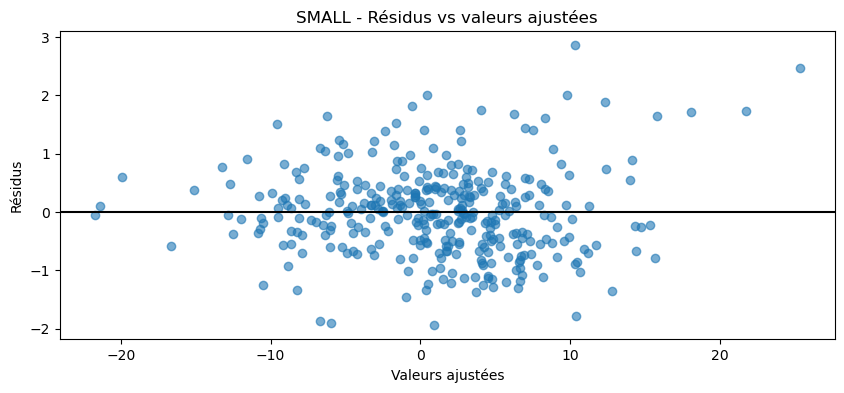

<Figure size 600x600 with 0 Axes>

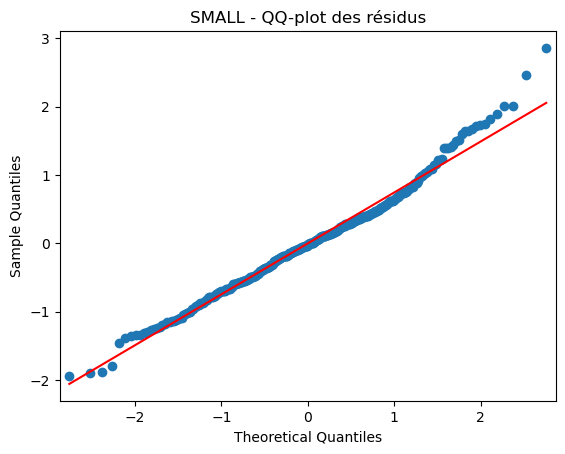

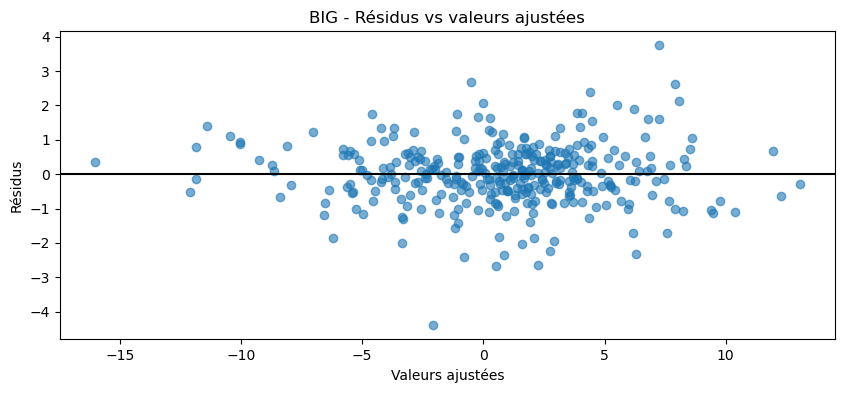

<Figure size 600x600 with 0 Axes>

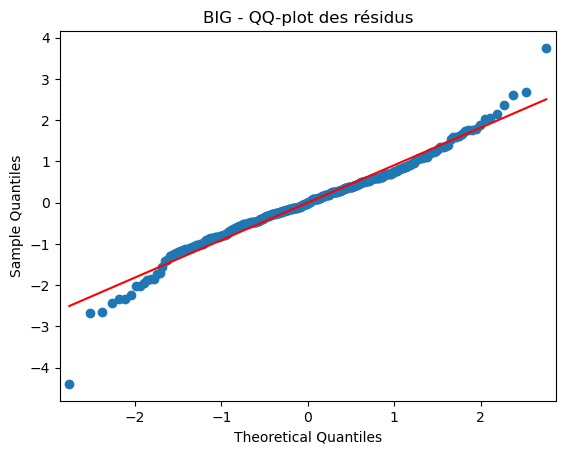

Graphiques de diagnostic sauvegardés en PNG.


In [71]:
# =========================================================
# Diagnostic des résidus + sauvegarde automatique des figures
# =========================================================

# Choix du modèle à diagnostiquer
model_small = m_small_ff      # ou m_small_ff_gepu
model_big   = m_big_ff        # ou m_big_ff_gepu

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Résidus et valeurs ajustées
resid_small  = model_small.resid
fitted_small = model_small.fittedvalues

resid_big  = model_big.resid
fitted_big = model_big.fittedvalues


def residual_plots(resid, fitted, prefix="model"):
    
    # 1️⃣ Résidus vs valeurs ajustées
    plt.figure(figsize=(10,4))
    plt.scatter(fitted, resid, alpha=0.6)
    plt.axhline(0, color="black")
    plt.title(f"{prefix} - Résidus vs valeurs ajustées")
    plt.xlabel("Valeurs ajustées")
    plt.ylabel("Résidus")
    plt.savefig(f"{prefix}_residus_vs_fitted.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
    # 2️⃣ QQ-plot
    plt.figure(figsize=(6,6))
    sm.qqplot(resid, line="s")
    plt.title(f"{prefix} - QQ-plot des résidus")
    plt.savefig(f"{prefix}_qqplot.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# Génération + sauvegarde
residual_plots(resid_small, fitted_small, "SMALL")
residual_plots(resid_big,   fitted_big,   "BIG")

print("Graphiques de diagnostic sauvegardés en PNG.")

Les graphiques des résidus en fonction des valeurs ajustées ne révèlent aucune structure particulière, les résidus étant centrés autour de zéro et ne présentant pas de forme systématique. Cela suggère une spécification correcte de l’équation de moyenne.

Les QQ-plots indiquent toutefois une légère déviation par rapport à la normalité dans les extrémités, particulièrement pour le portefeuille BIG, où l’on observe des queues plus épaisses. Ce résultat est cohérent avec les propriétés bien documentées des rendements financiers et justifie l’utilisation d’une distribution Student-t dans l’estimation du modèle GARCH.

<Figure size 1000x400 with 0 Axes>

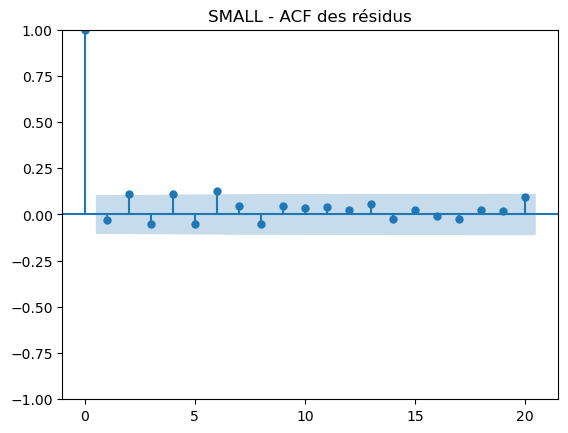

<Figure size 1000x400 with 0 Axes>

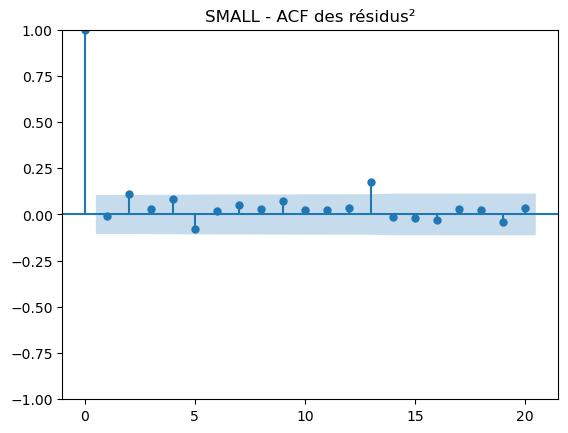

<Figure size 1000x400 with 0 Axes>

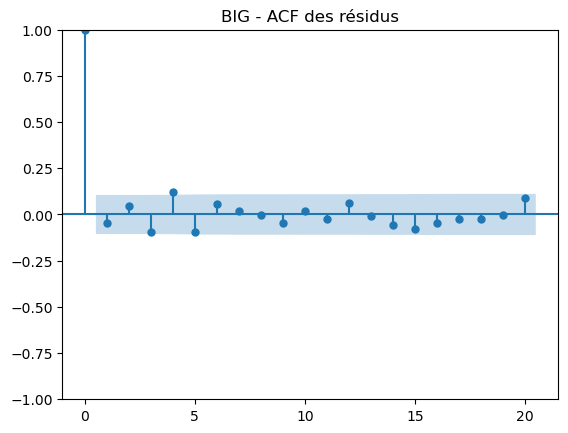

<Figure size 1000x400 with 0 Axes>

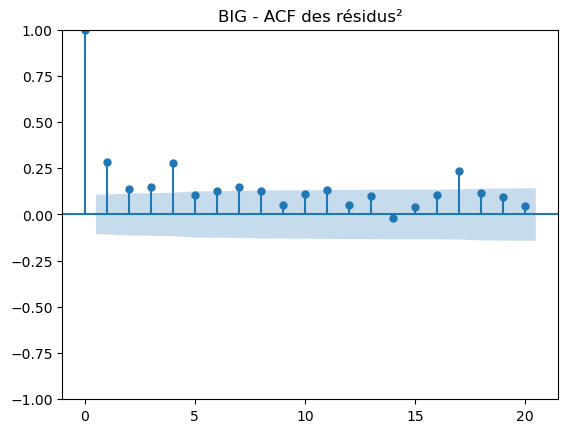

ACF sauvegardées en PNG.


In [72]:
# =========================================================
# ACF des résidus + sauvegarde automatique en PNG
# =========================================================

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

def acf_plots(resid, prefix="model"):
    
    # 1️⃣ ACF des résidus
    plt.figure(figsize=(10,4))
    plot_acf(resid, lags=20)
    plt.title(f"{prefix} - ACF des résidus")
    plt.savefig(f"{prefix}_acf_residus.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
    # 2️⃣ ACF des résidus² (clustering de volatilité)
    plt.figure(figsize=(10,4))
    plot_acf(resid**2, lags=20)
    plt.title(f"{prefix} - ACF des résidus²")
    plt.savefig(f"{prefix}_acf_residus_carre.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# Génération + sauvegarde
acf_plots(resid_small, "SMALL")
acf_plots(resid_big,   "BIG")

print("ACF sauvegardées en PNG.")

Les fonctions d’autocorrélation des résidus ne révèlent aucune dépendance significative, suggérant une spécification correcte de l’équation de moyenne pour les deux portefeuilles. En revanche, l’ACF des résidus au carré met en évidence une autocorrélation persistante pour le portefeuille BIG, traduisant la présence d’effets ARCH et d’un phénomène de clustering de volatilité. Cette dynamique justifie l’estimation d’un modèle GARCH pour le portefeuille BIG, tandis qu’aucune structure comparable n’est observée pour le portefeuille SMALL.

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_tests(resid, name=""):
    lb_resid = acorr_ljungbox(resid, lags=[12], return_df=True)
    lb_sq    = acorr_ljungbox(resid**2, lags=[12], return_df=True)

    print(f"--- {name} Ljung-Box (résidus) lag=12 ---")
    print(lb_resid)
    print()
    print(f"--- {name} Ljung-Box (résidus²) lag=12 ---")
    print(lb_sq)
    print()

ljung_tests(resid_small, "SMALL")
ljung_tests(resid_big,   "BIG")

--- SMALL Ljung-Box (résidus) lag=12 ---
      lb_stat  lb_pvalue
12  20.201118   0.063376

--- SMALL Ljung-Box (résidus²) lag=12 ---
      lb_stat  lb_pvalue
12  13.567714    0.32916

--- BIG Ljung-Box (résidus) lag=12 ---
      lb_stat  lb_pvalue
12  16.262919   0.179489

--- BIG Ljung-Box (résidus²) lag=12 ---
       lb_stat     lb_pvalue
12  106.404539  3.068926e-17



In [24]:
from statsmodels.stats.diagnostic import het_arch

def arch_test(resid, name=""):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(resid, nlags=12)
    print(f"--- {name} ARCH test (nlags=12) ---")
    print(f"LM stat = {lm_stat:.4f} | p-value = {lm_pvalue:.6f}")
    print(f"F  stat = {f_stat:.4f} | p-value = {f_pvalue:.6f}")
    print()

arch_test(resid_small, "SMALL")
arch_test(resid_big,   "BIG")

--- SMALL ARCH test (nlags=12) ---
LM stat = 12.9402 | p-value = 0.373400
F  stat = 1.0782 | p-value = 0.377829

--- BIG ARCH test (nlags=12) ---
LM stat = 52.8125 | p-value = 0.000000
F  stat = 5.0264 | p-value = 0.000000



Les tests de Ljung-Box appliqués aux résidus indiquent l’absence d’autocorrélation pour les deux portefeuilles (p-values supérieures à 5 %), ce qui confirme que la moyenne est correctement spécifiée par le modèle Fama-French. En revanche, l’analyse des résidus au carré révèle des différences importantes. Pour le portefeuille SMALL, ni le test de Ljung-Box sur les résidus² ni le test ARCH ne détectent d’hétéroscédasticité conditionnelle. La variance apparaît relativement stable dans le temps.

À l’inverse, pour le portefeuille BIG, les résultats sont très significatifs (p-value proche de zéro pour les deux tests), indiquant une forte dépendance temporelle dans la variance. Ce résultat met en évidence la présence d’un effet ARCH, caractéristique des séries financières. La volatilité du portefeuille BIG dépend donc de l’information passée, ce qui justifie l’estimation d’un modèle GARCH afin de modéliser explicitement cette dynamique.

“Compte tenu de la forte significativité du test ARCH sur le portefeuille BIG, nous estimons un modèle GARCH. Nous retenons une approche parcimonieuse en testant plusieurs spécifications (GARCH(1,1), (1,2), (2,1)) et deux distributions d’erreurs (normale et Student-t). Le modèle final est choisi selon les critères AIC/BIC et la disparition des effets ARCH dans les résidus standardisés.”

In [25]:
import sys
!{sys.executable} -m pip --version
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install --upgrade --no-cache-dir arch

pip 26.0.1 from C:\Users\lilia\anaconda3\Lib\site-packages\pip (python 3.13)



In [26]:
import arch
print(arch.__version__)
from arch import arch_model

8.0.0


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                 BIG_LoINV_RF   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3132.73
Distribution:      Standardized Student's t   AIC:                           6275.47
Method:                  Maximum Likelihood   BIC:                           6295.71
                                              No. Observations:                  424
Date:                      Mon, Mar 02 2026   Df Residuals:                      423
Time:                              16:03:26   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

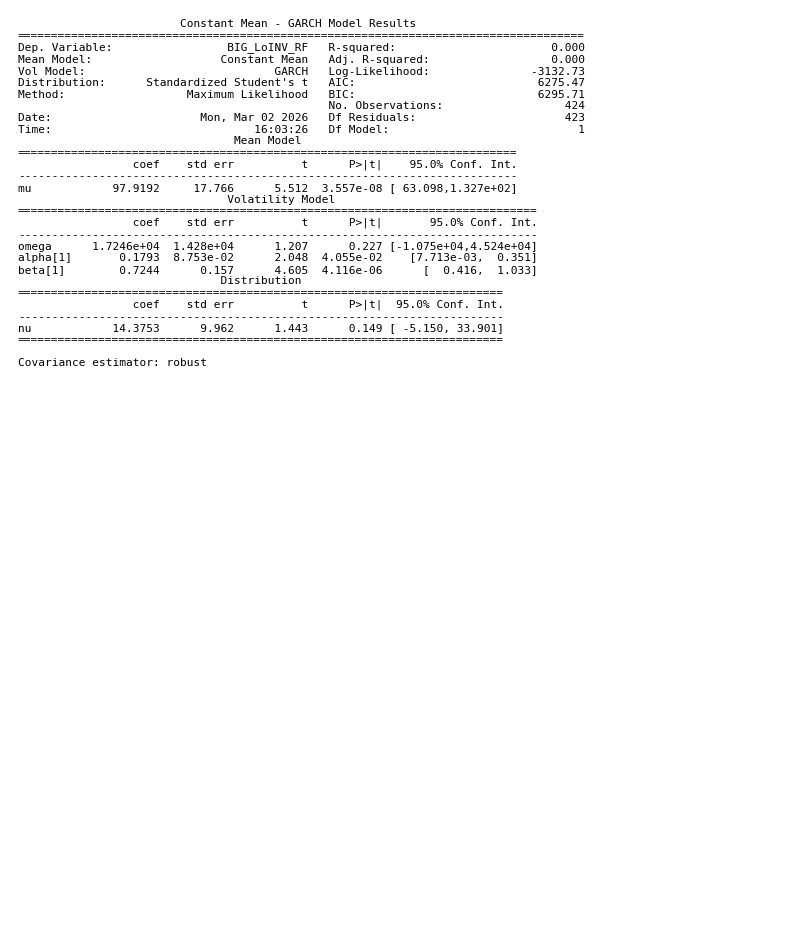

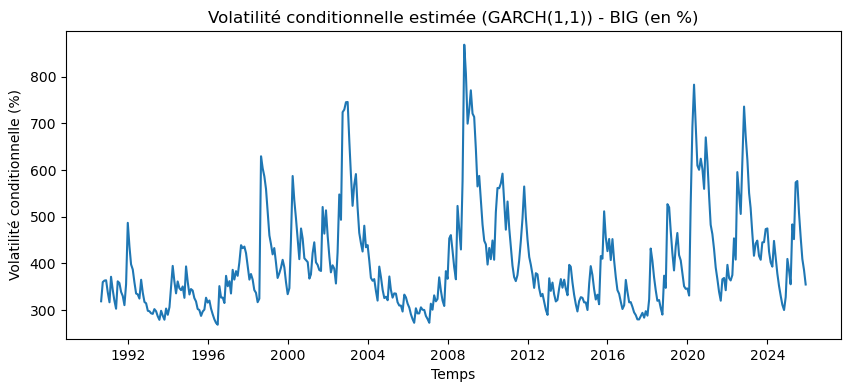

✅ Fichiers créés : summary_garch_BIG.png, summary_garch_BIG.txt, garch_volatility_BIG.png


In [73]:
# =========================================================
# GARCH(1,1) sur BIG + sauvegarde summary en PNG (+ txt) + volatilité
# =========================================================

from arch import arch_model
import matplotlib.pyplot as plt

# 1) Série : rendement excédentaire BIG en % (stabilité numérique)
big_excess_return = df["BIG_LoINV_RF"]
y = big_excess_return.dropna() * 100

# 2) Modèle GARCH(1,1) avec moyenne constante et Student-t
am = arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
res = am.fit(disp="off")

# 3) Affichage console
print(res.summary())

# =========================================================
# 4) Sauvegarde du summary en TXT
# =========================================================
with open("summary_garch_BIG.txt", "w") as f:
    f.write(str(res.summary()))

# =========================================================
# 5) Sauvegarde du summary en PNG
# =========================================================
summary_text = str(res.summary())

plt.figure(figsize=(10, 12))
plt.text(0.01, 0.99, summary_text,
         fontsize=8,
         va="top",
         family="monospace")
plt.axis("off")
plt.savefig("summary_garch_BIG.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================================================
# 6) Sauvegarde d'un graphique de volatilité conditionnelle
# =========================================================
cond_vol = res.conditional_volatility  # en % car y est en %
plt.figure(figsize=(10, 4))
plt.plot(cond_vol)
plt.title("Volatilité conditionnelle estimée (GARCH(1,1)) - BIG (en %)")
plt.xlabel("Temps")
plt.ylabel("Volatilité conditionnelle (%)")
plt.savefig("garch_volatility_BIG.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ Fichiers créés : summary_garch_BIG.png, summary_garch_BIG.txt, garch_volatility_BIG.png")

In [28]:
y = (df["BIG_LoINV_RF"].dropna()) * 100

results = []

for p, q in [(1,1), (1,2), (2,1)]:
    model = arch_model(y, mean="Constant", vol="GARCH", p=p, q=q, dist="t")
    res = model.fit(disp="off")
    results.append({
        "Model": f"GARCH({p},{q})",
        "AIC": res.aic,
        "BIC": res.bic
    })

pd.DataFrame(results).sort_values("BIC")

,Model,AIC,BIC
0,"GARCH(1,1)",6275.465405,6295.714072
1,"GARCH(1,2)",6277.204890,6301.503290
2,"GARCH(2,1)",6277.465405,6301.763806


Afin de modéliser la dynamique de la volatilité du portefeuille BIG, plusieurs spécifications ont été estimées, notamment les modèles GARCH(1,1), GARCH(1,2) et GARCH(2,1). La sélection a été effectuée à l’aide des critères d’information AIC et BIC.

Le modèle GARCH(1,1) présente le BIC le plus faible, indiquant le meilleur compromis entre qualité d’ajustement et parcimonie. Ce résultat est cohérent avec la littérature financière, dans laquelle le GARCH(1,1) constitue la spécification standard pour capturer la persistance de la volatilité.

Nous retenons donc le modèle GARCH(1,1) avec distribution Student-t pour l’analyse du portefeuille BIG.

Le coefficient de détermination concerne uniquement l’équation de moyenne. Dans notre spécification, celle-ci ne contient qu’une constante, ce qui explique un R² nul. L’objectif du modèle GARCH n’est pas d’expliquer la variance totale des rendements, mais de modéliser la dynamique de la variance conditionnelle. ( Le GARCH explique la variance conditionnelle dynamique.) 

Nous estimons un modèle GARCH(1,1) avec moyenne constante et erreurs suivant une distribution Student-t afin de capturer la dynamique de la volatilité du portefeuille BIG. 


Le modèle s’écrit : 𝑟 𝑡 = 𝜇 + 𝜀 𝑡 , avec 𝜀 𝑡 = 𝜎 𝑡 𝑧 𝑡   et 𝑧 𝑡 ∼ 𝑡 𝜈 ( 0 , 1 ) 


La variance conditionnelle suit la dynamique 𝜎 𝑡 2 = 𝜔 + 𝛼 𝜀 𝑡 − 1 + 𝛽 𝜎 𝑡 − 1


Le paramètre 𝜇 μ représente le rendement excédentaire moyen, tandis que 𝜔 ω correspond au niveau de volatilité de base. Les coefficients 𝛼 α et 𝛽 β mesurent respectivement l’impact des chocs passés et la persistance de la volatilité dans le temps.

L’estimation du modèle GARCH(1,1) avec distribution Student-t confirme la présence d’une dynamique significative de la volatilité pour le portefeuille BIG. Le coefficient α (0,179), significatif au seuil de 5 %, indique que les chocs récents affectent la volatilité future. Le coefficient β (0,724), hautement significatif, révèle une forte persistance de la volatilité.

La somme α + β = 0,903, inférieure à 1, garantit la stationnarité du processus tout en mettant en évidence une dynamique de volatilité durable. Ce résultat confirme la présence d’un phénomène de clustering de volatilité : les périodes de forte instabilité tendent à être suivies de nouvelles périodes d’instabilité.

Ainsi, bien que la moyenne des rendements excédentaires soit difficilement prévisible, la variance conditionnelle présente une structure dynamique marquée, justifiant pleinement l’utilisation d’un modèle GARCH pour le portefeuille BIG.

Ces résultats confirment que l’incertitude sur les rendements se manifeste principalement à travers la dynamique de la volatilité plutôt que dans la moyenne des rendements.

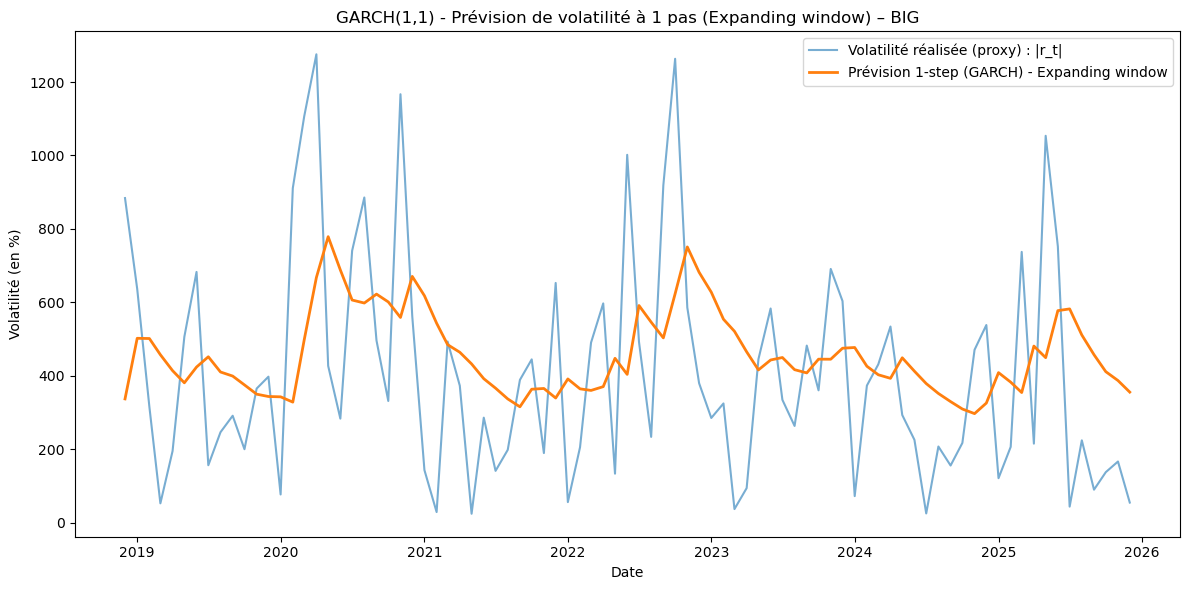

✅ Fichiers créés : garch_expanding_forecast_BIG.png et garch_expanding_forecast_BIG.csv


In [74]:
# =========================================================
# GARCH(1,1) Expanding window + sauvegarde PNG + export CSV
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# 1) Série en % (stabilité numérique)
y = df["BIG_LoINV_RF"].dropna() * 100

# 2) Train / Test
split = int(len(y) * 0.8)
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# 3) Volatilité "réalisée" (proxy simple) : |r_t|
sigma_real = y_test.abs()

# 4) Stockage des prévisions
sigma_pred_expanding = pd.Series(index=y_test.index, dtype=float)

# =========================================================
# 5) Expanding window : ré-estimation + prévision 1-step
# =========================================================
for t in y_test.index:
    # Données disponibles jusqu'à t-1
    end_loc = y.index.get_loc(t)
    y_known = y.iloc[:end_loc]

    try:
        # Ré-estimation
        am = arch_model(y_known, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
        res = am.fit(disp="off")

        # Prévision à 1 pas
        f = res.forecast(horizon=1, reindex=False)
        var_next = f.variance.values[-1, 0]   # variance prévue pour t
        sigma_pred_expanding.loc[t] = np.sqrt(var_next)

    except Exception as e:
        # Si une estimation plante à une date, on met NaN et on continue
        sigma_pred_expanding.loc[t] = np.nan

# =========================================================
# 6) Export CSV (pratique pour annexes et vérif)
# =========================================================
out = pd.DataFrame({
    "y_test_percent": y_test,
    "sigma_real_abs_rt": sigma_real,
    "sigma_pred_garch_expanding": sigma_pred_expanding
})
out.to_csv("garch_expanding_forecast_BIG.csv", index=True)

# =========================================================
# 7) Graphique + sauvegarde PNG
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(sigma_real.index, sigma_real.values,
         label="Volatilité réalisée (proxy) : |r_t|", alpha=0.6)

plt.plot(sigma_pred_expanding.index, sigma_pred_expanding.values,
         label="Prévision 1-step (GARCH) - Expanding window", linewidth=2)

plt.title("GARCH(1,1) - Prévision de volatilité à 1 pas (Expanding window) – BIG")
plt.xlabel("Date")
plt.ylabel("Volatilité (en %)")
plt.legend()
plt.tight_layout()

plt.savefig("garch_expanding_forecast_BIG.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✅ Fichiers créés : garch_expanding_forecast_BIG.png et garch_expanding_forecast_BIG.csv")

La comparaison entre la volatilité réalisée et la volatilité prévue montre que le modèle GARCH(1,1) capture correctement la dynamique générale du risque. La volatilité conditionnelle estimée réagit aux périodes de forte instabilité et reproduit les cycles de hausse et de baisse du risque. Toutefois, comme attendu, la prévision demeure plus lisse que la volatilité réalisée, les pics extrêmes étant partiellement atténués en raison de la structure persistante du modèle.

La volatilité prévue ne reproduit pas parfaitement les pics extrêmes de la volatilité réalisée, ce qui est attendu puisque le modèle GARCH capture la dynamique persistante du risque plutôt que les chocs imprévus. Néanmoins, il suit correctement les phases de hausse et de baisse de l’instabilité.

Out-of-sample one-step-ahead forecast with expanding window

La moyenne n’est pas prédictible.
Mais la volatilité l’est.

Et ça, c’est un résultat important.

Le graphique présente la validation prédictive du modèle GARCH(1,1) à l’aide d’une approche en expanding window. La courbe bleue correspond à la volatilité réalisée, mesurée ici par la valeur absolue des rendements, tandis que la courbe orange représente la volatilité conditionnelle prévue à un pas ( 𝜎 ^ 𝑡 ∣ 𝑡 − 1 σ ^ t∣t−1 ​ ), obtenue en ré-estimant le modèle à chaque période en utilisant uniquement l’information disponible jusqu’à 𝑡 − 1 t−1. On observe que la prévision est nettement plus lisse que la volatilité réalisée, ce qui est attendu puisque le GARCH modélise la dynamique persistante de la variance plutôt que les chocs ponctuels. La volatilité prévue augmente à la suite des épisodes de forte instabilité et diminue progressivement lors des phases plus calmes, traduisant la mémoire du processus. Ainsi, même si la prévision ne reproduit pas les pics exacts des rendements, elle capture les régimes de volatilité élevée et faible, ce qui confirme la capacité du modèle à anticiper l’évolution du risque de manière conditionnelle.

Le modèle GARCH ne prédit pas les pics de volatilité, car ceux-ci résultent de chocs imprévisibles. Il prévoit plutôt le niveau de risque attendu et sa persistance, en capturant les phases de forte ou de faible volatilité au fil du temps.

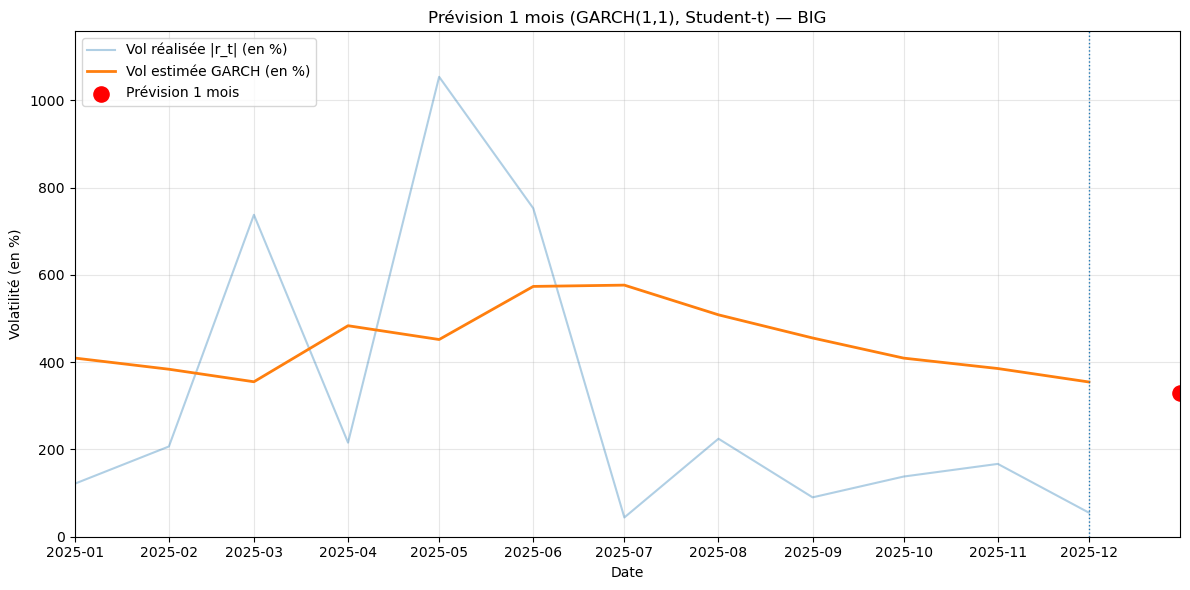

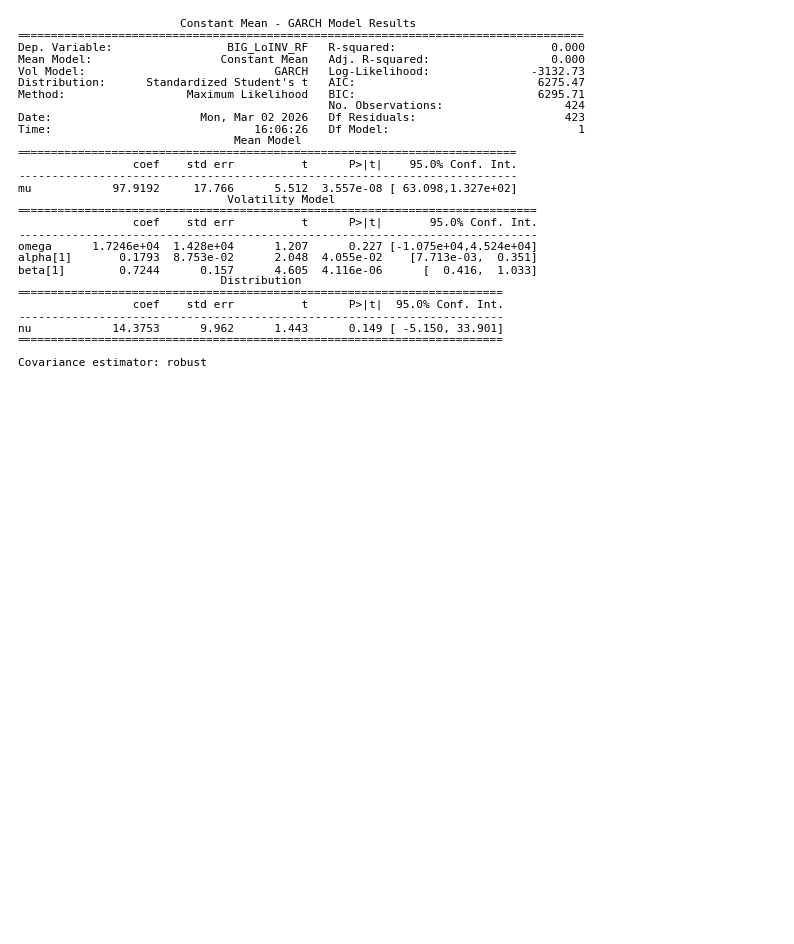

Dernière date base : 2025-12-01 00:00:00
Date prévue        : 2025-12-31 00:00:00
Volatilité prévue (en %) : 329.52678773498013
✅ Fichiers créés :
 - garch_1month_forecast_BIG_2025_zoom.png
 - garch_1month_forecast_BIG_series.csv
 - summary_garch_BIG_fullsample.txt
 - summary_garch_BIG_fullsample.png


In [75]:
# =========================================================
# GARCH(1,1) sur toute la base + prévision 1 mois + sauvegardes (PNG/CSV/summary)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# --- Série en % (stabilité numérique) ---
y = df["BIG_LoINV_RF"].dropna() * 100
y.index = pd.to_datetime(y.index)
y = y.sort_index()

# --- Estimation sur toute la base (jusqu'à la dernière date dispo, idéalement Dec 2025) ---
am = arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
res = am.fit(disp="off")

# --- Prévision 1-step (mois suivant : Jan 2026 si base finit en Dec 2025) ---
f = res.forecast(horizon=1, reindex=False)
var_next = f.variance.values[-1, 0]
sigma_next = float(np.sqrt(var_next))

last_date = y.index[-1]
future_date = last_date + pd.offsets.MonthEnd(1)

# --- Séries pour le plot ---
sigma_real = y.abs()                         # proxy simple
sigma_fitted = pd.Series(res.conditional_volatility, index=y.index)

# --- Zoom : 2025 -> date future ---
start_zoom = pd.Timestamp("2025-01-01")
real_zoom = sigma_real.loc[start_zoom:last_date]
fit_zoom  = sigma_fitted.loc[start_zoom:last_date]

# =========================================================
# 1) Graphique + sauvegarde PNG
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(real_zoom.index, real_zoom.values, label="Vol réalisée |r_t| (en %)", alpha=0.35)
plt.plot(fit_zoom.index,  fit_zoom.values,  label="Vol estimée GARCH (en %)", linewidth=2)

plt.scatter([future_date], [sigma_next], color="red", s=120, label="Prévision 1 mois")
plt.axvline(last_date, linestyle=":", linewidth=1)

plt.xlim(start_zoom, future_date)
ymax = max(real_zoom.max(), fit_zoom.max(), sigma_next) * 1.10
plt.ylim(0, ymax)

plt.title("Prévision 1 mois (GARCH(1,1), Student-t) — BIG")
plt.xlabel("Date")
plt.ylabel("Volatilité (en %)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("garch_1month_forecast_BIG_2025_zoom.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================================================
# 2) Export CSV (utile pour annexes / vérif)
# =========================================================
out = pd.DataFrame({
    "sigma_real_abs_rt": sigma_real,
    "sigma_fitted_garch": sigma_fitted
})
out.loc[future_date, "sigma_real_abs_rt"] = np.nan
out.loc[future_date, "sigma_fitted_garch"] = sigma_next
out.to_csv("garch_1month_forecast_BIG_series.csv", index=True)

# =========================================================
# 3) Sauvegarde summary en TXT + PNG (annexe)
# =========================================================
summary_text = str(res.summary())

with open("summary_garch_BIG_fullsample.txt", "w") as ftxt:
    ftxt.write(summary_text)

plt.figure(figsize=(10, 12))
plt.text(0.01, 0.99, summary_text, fontsize=8, va="top", family="monospace")
plt.axis("off")
plt.savefig("summary_garch_BIG_fullsample.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# =========================================================
# 4) Print infos
# =========================================================
print("Dernière date base :", last_date)
print("Date prévue        :", future_date)
print("Volatilité prévue (en %) :", sigma_next)
print("✅ Fichiers créés :")
print(" - garch_1month_forecast_BIG_2025_zoom.png")
print(" - garch_1month_forecast_BIG_series.csv")
print(" - summary_garch_BIG_fullsample.txt")
print(" - summary_garch_BIG_fullsample.png")

Paragraphe d’interprétation (court) :
La prévision à un mois du modèle GARCH(1,1) fournit une estimation de la volatilité conditionnelle attendue pour la période suivante (janvier 2026 si l’échantillon se termine en décembre 2025). Cette valeur prolonge la dynamique récente de la volatilité estimée : le modèle ne cherche pas à anticiper un choc ponctuel, mais à projeter le niveau moyen de risque à court terme compte tenu de l’information disponible en fin de période.

Sur ce graphique, la prévision ne cherche pas à annoncer un pic ou un événement particulier. Elle prolonge simplement la dynamique récente de la volatilité estimée. Comme le risque était en baisse progressive en fin d’année, le modèle prévoit que le mois suivant restera dans un régime relativement modéré, sauf choc imprévu. Autrement dit, il ne prédit pas un mouvement spectaculaire, mais il indique que, compte tenu des informations disponibles, le niveau de risque devrait rester proche de celui observé récemment.Parce que le GARCH modélise la persistance du risque, pas les chocs eux-mêmes.

In [ ]:
df.